# Demo: Klyngeanalyse

Denne demonstrasjonen gjev ein rudimentær implementasjon av $k$-means.
Hensikta er å visa korleise modellen utviklar seg for kvar iterasjon.

Det er ikkje meininga, på dette stadiet, å gje ein fullverdig introduksjon her.
Poenget er grafane som eg bruker i eit føredrag.

## Definisjon av $k$-*means*

Den aller best kjende algoritmen for maskinlæring utan rettleiing
(*unsupervised learning*) heiter $k$-*means*.  Hensikta med $k$-*means*
er å ta eit datasett og dela det inn i $k$ klyngar (*clusters*) med
datapunkt som liknar på kvarandre.

Kvart datapunkt er ein vektor i eit $n$-dimensonalt rom, dvs. tuplar
av $n$ tal.  For at $k$-*means* skal fungera godt, må me normalisera
datasettet slik at alle variablane har om lag same omfang.  Dvs.
at kvar variabel (søyle) vert skalert. Dei to vanlegaste teknikkane
er å skalera slik at alle verdiane fell i intervallet $(0,1)$, eller
slik at gjennomsnittet vert 0 og utvalsstandardavviket 1.

I $k$-*means* vert kvar klynge representert ved ein vektor.
Målet når algoritmen er ferdig, er to eigenskapar
1.  Den representative vektoren er gjennomsnittet av alle vektorane i klynga.
2.  Kvar vektor i datasettet vert assosiert med den representative vektoren
    som ligger nærast (kortast euklidsk avstand).

For å nå dette målet vil algoritmen iterativt oppdatera løysinga og vekselsvis
oppnå mål 1 og mål 2.  For kvar iterasjon vert feilen i kvar eigenskap mindre.

Algoritmen startar med $k$ tilfeldig valde representative vektorar.  
I kvar iterasjon vil algoritmen
1.  Assosiera kvart datapunkt med den næraste representative vektoren og
    oppdatera klyngane.
2.  Rekna eit nytt sett med representative vektorar ved å ta gjennomsnittet
    av kvar klynge.

Algoritmen terminerer når ingen vektorar lenger byter klynge.
Det kan vera naudsynt å setja andre stoppvilkår dersom ei perfekt
løysing ikkje finst eller datasettet er svært stort.

## Konfigurasjon

I dette dømet skal me implementera $k$-means frå botnen av, so me
importerer berre `numpy` for matriserekning og `pyplot` for visualisering.

In [57]:
import numpy as np
import matplotlib.pyplot as plt

Her vil me bruka konstant $k=3$ i $k$-*means*-*clustering*.
Me skal laga eit datasett med kring 100 (`size`) datapunkt per klynge.

In [58]:
k = 3
size = 100

## Tilfeldig generert datasett

For å få gode illustrasjonar vil me laga eit tilfeldig datasett med
tre overlappande klyngar.  Dette gjer me ved å trekkja tre normalfordelte
utval med litt ulike gjennomsnitt ($\mu$) og standardavvik ($\sigma$).
Av omsyn til visualiseringa har me berre to søyler i datasettet.

In [59]:
a = np.random.normal( size=[size, 2], loc=(2,0), scale=(0.6,1) )
b = np.random.normal( size=[size, 2], loc=(0,2), scale=(1.2,0.7) )
c = np.random.normal( size=[size, 2], loc=(-1,-1), scale=(1,1) )

Funksjonen `normal` gjev tilfeldige, normalfordelte verdiar.
Her er `loc` gjennomsnittet i kvar dimensjon og `scale` standardavviket.
For å visa kva me har generert, kan me visualisera med eit spreideplott.

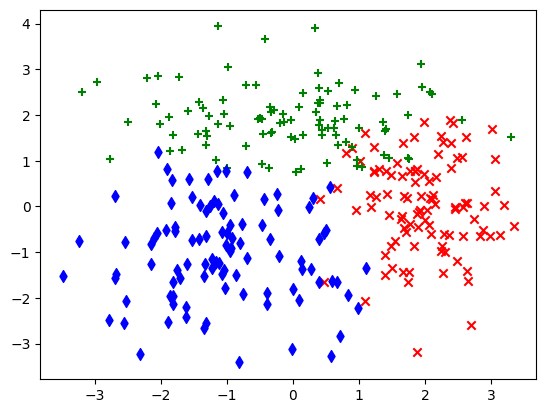

In [60]:
plt.scatter( a[:,0], a[:,1], c="r", marker="x" )
plt.scatter( b[:,0], b[:,1], c="g", marker="+" )
plt.scatter( c[:,0], c[:,1], c="b", marker="d" )

Til sist skal me setja saman datasettet til éi matrise.

In [61]:
data0 = np.vstack( [ a,b,c] )
print( data0 )

[[ 1.46207008 -0.19308004]
 [ 1.43278269  0.28358866]
 [ 1.99062862  1.839979  ]
 [ 2.16543801  0.64337309]
 [ 0.79751969  1.17605253]
 [ 2.36489446 -0.62533103]
 [ 2.06287706  0.55601533]
 [ 3.19437832  0.03783421]
 [ 2.48255471 -1.19297031]
 [ 2.06556443 -0.40946076]
 [ 3.01267819  1.70085509]
 [ 1.49358334  0.68523167]
 [ 1.87441127 -3.17897086]
 [ 2.27205365 -1.44783336]
 [ 3.34476934 -0.42887382]
 [ 2.43303742  1.82584887]
 [ 3.13295215 -0.63048102]
 [ 0.41601827  0.16753822]
 [ 1.23162173  1.29631267]
 [ 1.25787099  0.19898489]
 [ 3.06355994  1.04865599]
 [ 2.56788414  1.08910187]
 [ 2.46230536 -0.01599849]
 [ 2.65058999 -1.62844342]
 [ 0.9616292  -0.08160972]
 [ 1.67795834  0.21990348]
 [ 2.4583474  -0.05977   ]
 [ 2.0779014   0.18751118]
 [ 2.15305236  0.06406686]
 [ 2.12407757  0.2574446 ]
 [ 2.26521204 -0.86860961]
 [ 2.00153962 -0.30648775]
 [ 1.08872499  1.60136808]
 [ 1.71989127 -0.55519801]
 [ 2.24535851 -0.9726033 ]
 [ 1.65175385 -0.21855977]
 [ 1.84030046 -0.85935164]
 

Me definerer òg *ground truth* til seinare evaluering.
Dvs. ein vektor med eitt element (0, 1 eller 2) for kvar rad i `data0`.

In [62]:
gt0 = np.vstack( [ np.zeros( [size, 1] ), np.ones([size,1]), np.ones([size,1])*2 ] )
print( gt0.T )

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
  2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
  2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
  2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
  2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]]


*Merk* at me skriv ut den transponerte for at utskrifta skal ta mindre plass.

Algoritmen skal sjølvsagt ikkje ha informasjon om *ground truth*.
Difor skal me stokka radane tilfeldig.  
For å kunna stokka både `data0` og `gt0` lagar me fyrst ei liste med
indeksar som vert stokka, og so bruker me dei til å stokka datasettet.

In [63]:
idx = np.arange(300)
np.random.shuffle( idx )
print( idx )

[ 14  20 230 204  34 156 144 248 198 291 169 226   2 139 133   7 293  10
  53 125 245 238  84 262 234 159 129  19 118  31 186 240 143 244  65 158
 243  55 280  39  74 299  50 298 147 127 205 197  15 256  68 155  54  29
 138  26 286 176 196  28  56 114  60 223 253  87 185 172 154 151  43 171
  27 221 166 108  85 215 236 282  36  51  96 163 188 112 136  78 148 278
  94  90 150   9 222  82 264 120 259 126 276 189 232  23  69  80 277 105
 257 177 193  35 128 239 275 267 145  47   0 123 130 296  42  18 107 179
  48  49  21 164  64 117 153 268 170 235 247 111 167 100 199 194 233 297
 279   4   1  12 250 141 140 180  32 209 252  91 213 217  73 121  77  25
   5  33 195 152 175 260 210 201 228 190 242 255  22  59 178 116 181 115
 202 295 283 241 214 207 285  38  70 270  61 109  75  92 131 149 157  57
  89  17 220  79 287 134  11 146  41 271 183 269  83  88 160 132 200  67
  86 227 216 184 122 206  81  16 225 288  45  95 113   8  63  24 212  13
 263 182 102  52 103 281 162 119 135 274  97 249 20

In [64]:
data = data0[idx,:]
gt = gt0[idx,:]
print( gt.T )

[[0. 0. 2. 2. 0. 1. 1. 2. 1. 2. 1. 2. 0. 1. 1. 0. 2. 0. 0. 1. 2. 2. 0. 2.
  2. 1. 1. 0. 1. 0. 1. 2. 1. 2. 0. 1. 2. 0. 2. 0. 0. 2. 0. 2. 1. 1. 2. 1.
  0. 2. 0. 1. 0. 0. 1. 0. 2. 1. 1. 0. 0. 1. 0. 2. 2. 0. 1. 1. 1. 1. 0. 1.
  0. 2. 1. 1. 0. 2. 2. 2. 0. 0. 0. 1. 1. 1. 1. 0. 1. 2. 0. 0. 1. 0. 2. 0.
  2. 1. 2. 1. 2. 1. 2. 0. 0. 0. 2. 1. 2. 1. 1. 0. 1. 2. 2. 2. 1. 0. 0. 1.
  1. 2. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 2. 1. 2. 2. 1. 1. 1. 1. 1. 2. 2.
  2. 0. 0. 0. 2. 1. 1. 1. 0. 2. 2. 0. 2. 2. 0. 1. 0. 0. 0. 0. 1. 1. 1. 2.
  2. 2. 2. 1. 2. 2. 0. 0. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 0. 0. 2. 0. 1.
  0. 0. 1. 1. 1. 0. 0. 0. 2. 0. 2. 1. 0. 1. 0. 2. 1. 2. 0. 0. 1. 1. 2. 0.
  0. 2. 2. 1. 1. 2. 0. 0. 2. 2. 0. 0. 1. 0. 0. 0. 2. 0. 2. 1. 1. 0. 1. 2.
  1. 1. 1. 2. 0. 2. 2. 0. 2. 2. 1. 1. 2. 1. 2. 1. 1. 1. 2. 2. 1. 0. 2. 2.
  0. 2. 0. 2. 2. 1. 1. 0. 0. 0. 2. 1. 2. 2. 0. 1. 2. 2. 0. 0. 0. 0. 1. 0.
  2. 2. 2. 2. 1. 0. 1. 1. 0. 0. 2. 2.]]


Indekseringa med `idx` over tek alle elementa, men i ny rekkjefylge.
Dermed kjem ikkje alle datapunkta frå same klasse etter kvarandre.

For å testa at datasettet stadig er rett, kan me plotta og samanlikna med spreideplottet over.

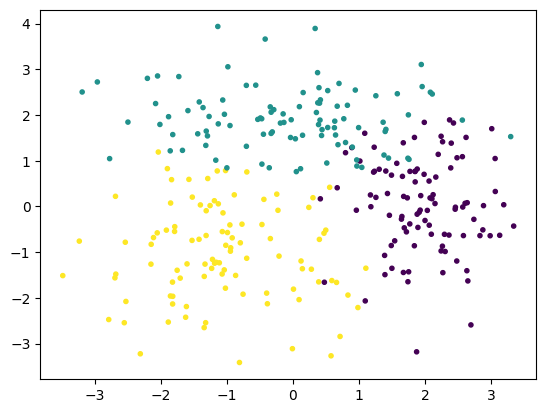

In [65]:
plt.scatter( data[:,0], data[:,1], c=gt, marker="." )

Dette ser rimeleg ut.

## Implementasjon av $k$-*means*

No må me definera ein tentativ modell, som består av $k$ vilkårleg valde punkt,
som representerer dei $k$ klyngane som me skal finna.

In [66]:
model = np.random.normal( size=(3,2))
print(model)

[[3.3058092  1.36302006]
 [0.78069375 1.72207772]
 [0.64688718 0.50262718]]


For å sjekka at alt er rett kan me plotta datasettet saman med modellpunkta, slik.

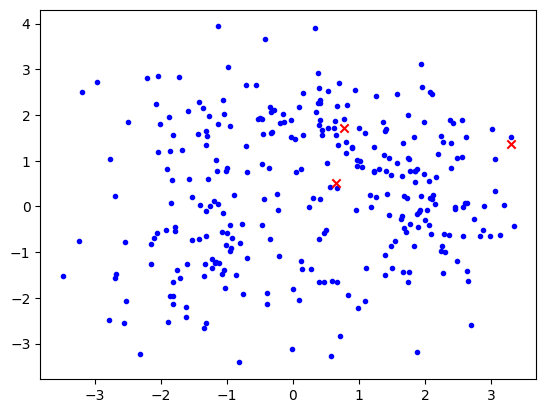

In [67]:
plt.scatter( data[:,0], data[:,1], c="b", marker="." )
plt.scatter( model[:,0], model[:,1], c="r", marker="x" )

Modellen er sjølvsagt ikkje god. Modellpunkta er klynga saman og er lite representative for spreidinga i datasettet,
men so var dei òg tilfeldig valde.

## Predict

I $k$-means er der to steg som vert gjentekne.  Det fyrste er prediksjonen, 
der kvart datapunkt vert assosiert med det næraste modellpunktet.
Den fylgjande funksjonen gjer denne jobben. Returverdien er ein vektor med
eitt element for kvart datapunkt, der verdien er indeksen åt det næraste modellpunktet.

In [68]:
def predict( a, m ):
    A = a[np.newaxis,:,:]
    M = m[:,np.newaxis,:]
    diff = A - M
    dist = (diff**2).sum(axis=2)
    return dist.argmin(axis=0)

Me treng òg ein funksjon for å plotta datasettet med ulike farger for kvar klynge.

In [69]:
def kmplot( data, model, pred ):
    plt.scatter( data[:,0], data[:,1], c=p, marker="." )
    plt.scatter( model[:,0], model[:,1], c="k", marker="x" )

No kan me gjera prediksjonen og plotta resultatet, ved hjelp av funksjonane.

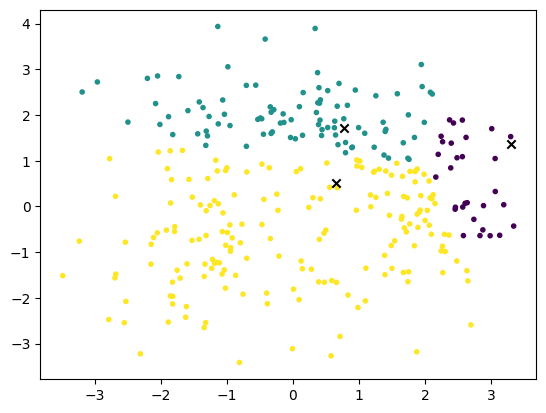

In [70]:
p = predict( data, model )
kmplot( data, model, p )

Modellpunkta er stadig dei same, men no kan me sjå kva datapunkt som høyrer til same klynge.
Det neste steget er å revidera modellen.  Fylgjande funksjon reknar ut nye modellpunkt som
gjennomsnittet frå kvar klynge.

In [71]:
def means( a, p ):
    l = []
    for i in range(k):
        t = a[ p==i, : ]
        l.append( t.mean(axis=0) )
    return np.vstack( l )

No kan me bruka denne funksjonen og plotta på nytt.

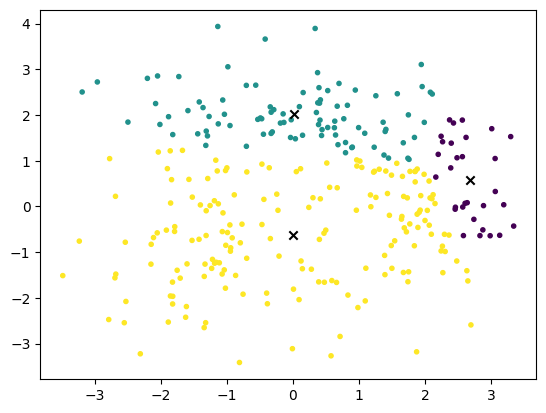

In [72]:
model = means( data, p )
kmplot( data, model, p )

Klyngene er dei same som sist, men me kan sjå korleis modellpunkta har flytta seg.

No kan me gjenta heile prosessen.

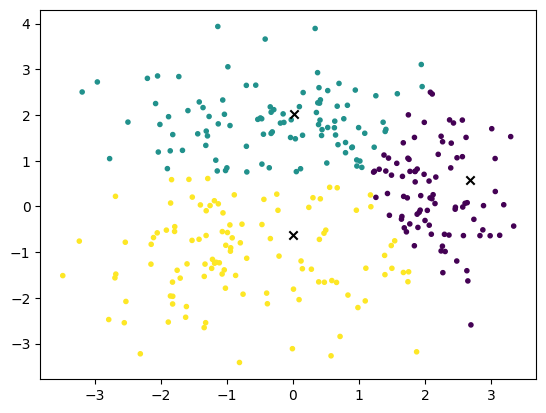

In [73]:
p = predict( data, model )
kmplot( data, model, p )

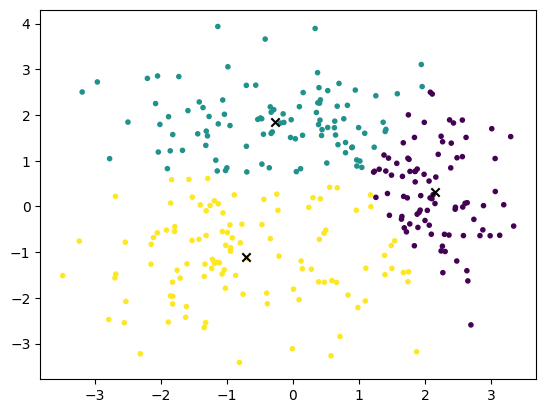

In [74]:
model = means( data, p )
kmplot( data, model, p )

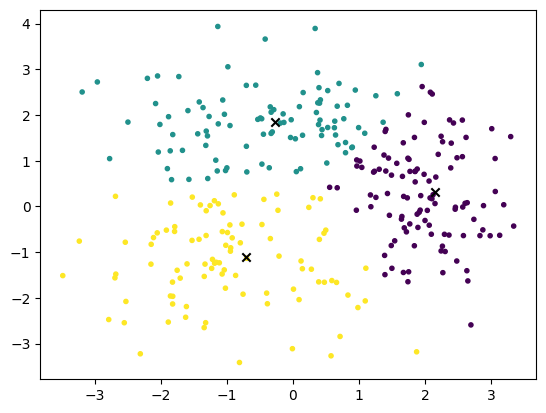

In [75]:
p = predict( data, model )
kmplot( data, model, p )

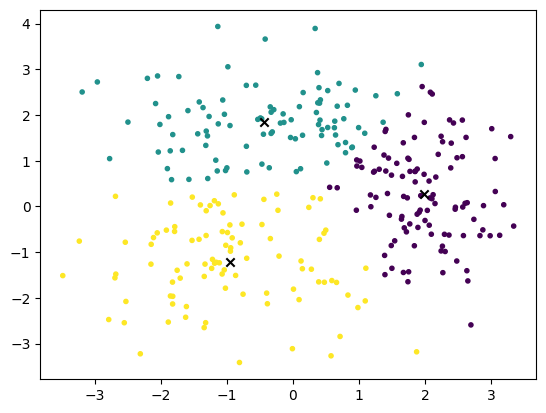

In [76]:
model = means( data, p )
kmplot( data, model, p )

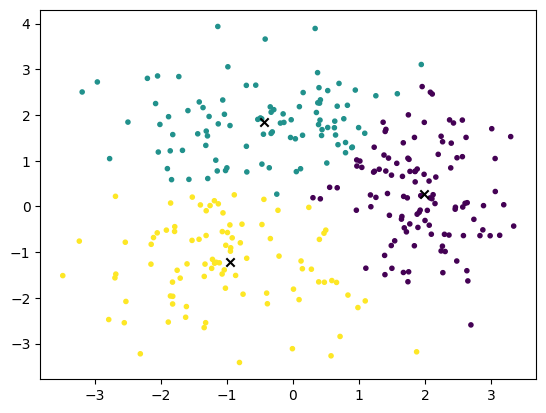

In [77]:
p = predict( data, model )
kmplot( data, model, p )

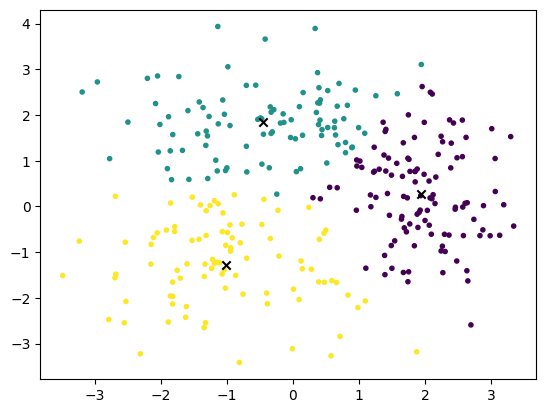

In [78]:
model = means( data, p )
kmplot( data, model, p )

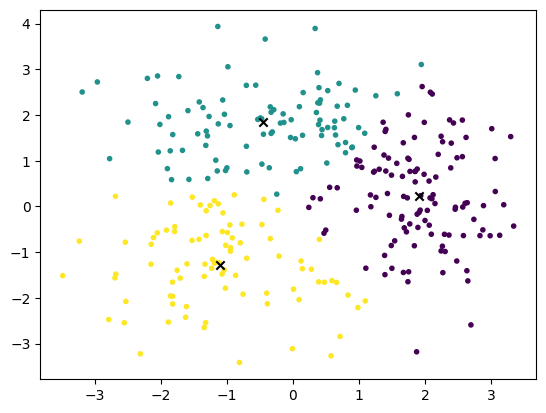

In [79]:
for i in range(1000):
   p = predict( data, model )
   model = means( data, p )
kmplot( data, model, p )

Det er ikkje sikkert at dei identifiserte klyngene stemmer med dei opprinnelege, men det kan vera gøy å samanlikna.
Då kan me bruka ulike farger for predikerte klasser og ulike symbol for *ground truth*.  Diverre kan me ikkje bruka ein `array` som `marker` på same måte som me gjer med `c`, so me må dela datasettet opp.

Me startar med å definera indeksane for kvar *ground truth*-klasse.

In [80]:
idx0 = gt == 0
idx1 = gt == 1
idx2 = gt == 2
print( idx0.T )
print( idx1.T )
print( idx2.T )

[[ True  True False False  True False False False False False False False
   True False False  True False  True  True False False False  True False
  False False False  True False  True False False False False  True False
  False  True False  True  True False  True False False False False False
   True False  True False  True  True False  True False False False  True
   True False  True False False  True False False False False  True False
   True False False False  True False False False  True  True  True False
  False False False  True False False  True  True False  True False  True
  False False False False False False False  True  True  True False False
  False False False  True False False False False False  True  True False
  False False  True  True False False  True  True  True False  True False
  False False False False False False False False False False False False
  False  True  True  True False False False False  True False False  True
  False False  True False  True  True 

No kan me plotta kvar *ground truth*-klasse med ulik `marker`.

In [81]:
plt.scatter( data[idx0,0], data[idx0,1], c=p[idx0], marker="+" )
plt.scatter( data[idx1,0], data[idx1,1], c=p[idx1], marker="x" )
plt.scatter( data[idx2,0], data[idx2,1], c=p[idx2], marker="o" )
plt.scatter( model[:,0], model[:,1], c="k", marker="x" )

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

Det gjekk visst ikkje.  Me har brukt tre indeksar i ei todimensjonal matrise.  Det er vanskeleg å sjå kvar det kan vera.
Me har éin indeks på `p`, to på `modell` og to på `data`, men `idx` er ein `array` med to dimensjonar, og dermed indekserar me tre dimensjonar i `data`.
Løysinga er å flata ut `idx`.  Ho har berre éi søyle.

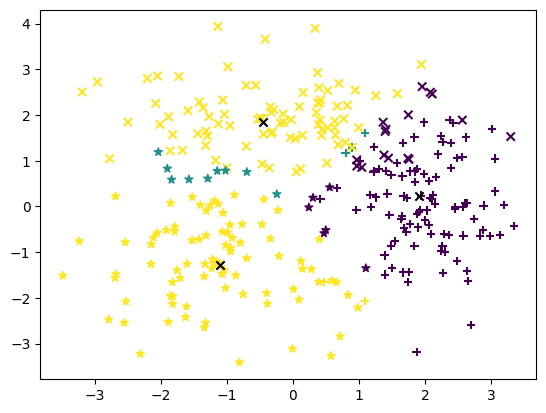

In [82]:
idx0 = idx0.flatten()
idx1 = idx1.flatten()
idx2 = idx2.flatten()
plt.scatter( data[idx0,0], data[idx0,1], c=p[idx0], marker="+" )
plt.scatter( data[idx1,0], data[idx1,1], c=p[idx1], marker="x" )
plt.scatter( data[idx2,0], data[idx2,1], c=p[idx2], marker="*" )
plt.scatter( model[:,0], model[:,1], c="k", marker="x" )

Dette vart òg rart.  Det ser ikkje ut som om same tal gjev same farge i kvart kall til `scatter`. 
Det ser ein òg om ein slår opp i [dokumentasjonen](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html).
Fargen avheng av fleire faktorar.

Dette kan me fiksa ved å byta ut tala med farger i `p`.

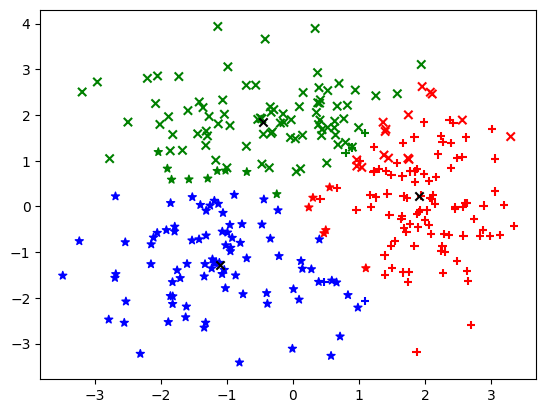

In [83]:
pc = p.astype(str)
pc[ pc == "0" ] = "r"
pc[ pc == "1" ] = "g"
pc[ pc == "2" ] = "b"
plt.scatter( data[idx0,0], data[idx0,1], c=pc[idx0], marker="+" )
plt.scatter( data[idx1,0], data[idx1,1], c=pc[idx1], marker="x" )
plt.scatter( data[idx2,0], data[idx2,1], c=pc[idx2], marker="*" )
plt.scatter( model[:,0], model[:,1], c="k", marker="x" )

Det vart litt omstendeleg, men eg valde å visa nokre av dei feila som eg gjorde på vegen.

Me ser ganske godt samsvar mellom dei opprinnelege klyngene og prediksjonane, sjølv om det ikkje er perfekt.

## Skisser til grunnleggjande syntaks

Det siste avsnittet er prøving og feiling med grunnleggjande syntaks.

In [84]:
a = np.array( [[[1, 2,3 ],[ 1,0,2]]] ) *2
b = np.array( [[[ 2,2,2]],[[ 1, 1,1]] ] ) 
print(b)

[[[2 2 2]]

 [[1 1 1]]]


In [85]:
c = a-b
print(c)

[[[ 0  2  4]
  [ 0 -2  2]]

 [[ 1  3  5]
  [ 1 -1  3]]]


In [86]:
c.shape

(2, 2, 3)

In [87]:
d= c**2
print(d)

[[[ 0  4 16]
  [ 0  4  4]]

 [[ 1  9 25]
  [ 1  1  9]]]


In [88]:
dist = d.sum( axis=2 )
print(dist)

[[20  8]
 [35 11]]


In [89]:
dist.argmin(axis=0)

array([0, 0])